# Function 2 — 2D Log-Likelihood Maximisation

**Surrogate:** GP with Matérn 5/2 kernel
**Acquisition:** Expected Improvement (EI)

EI was chosen over UCB because it focuses on regions likely to *beat the
current best*, rather than simply on high mean or high uncertainty. The
problem description warns that the surface is multimodal and that it is
possible to get stuck in a local optimum, which is exactly the situation EI
handles better.

---

Two inputs in [0, 1], returning a log-likelihood score from a hidden ML
model. One query per week.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import LeaveOneOut
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

## 1. Data

Loaded from `../data/function_2.csv` rather than pasted inline, so the
notebook and the stored dataset can never drift apart.

The `week` column records when each point was added: `0` for the supplied
starting data, `1`–`5` for the rounds submitted during the project.

In [2]:
# -----------------------------------------------------------------
#  DATA
# -----------------------------------------------------------------
df = pd.read_csv("../data/function_2.csv", float_precision="round_trip")

X    = df[["x1", "x2"]].values     # input points
Y    = df["y"].values              # score returned for each point
week = df["week"].values           # 0 = supplied, 1-5 = submitted by us

print("Data shapes:")
print(f"  X : {X.shape}")
print(f"  Y : {Y.shape}")
print(f"\nY range : [{Y.min():.6g},  {Y.max():.6g}]")

df.tail()

Data shapes:
  X : (15, 2)
  Y : (15,)

Y range : [-0.0656236,  0.611205]


,week,x1,x2,y
10,1,0.730000,0.930000,0.554417
11,2,0.857143,0.979592,0.084334
12,3,0.673469,0.285714,0.537646
13,4,0.775510,0.204082,0.239744
14,5,0.676768,0.969697,0.498074


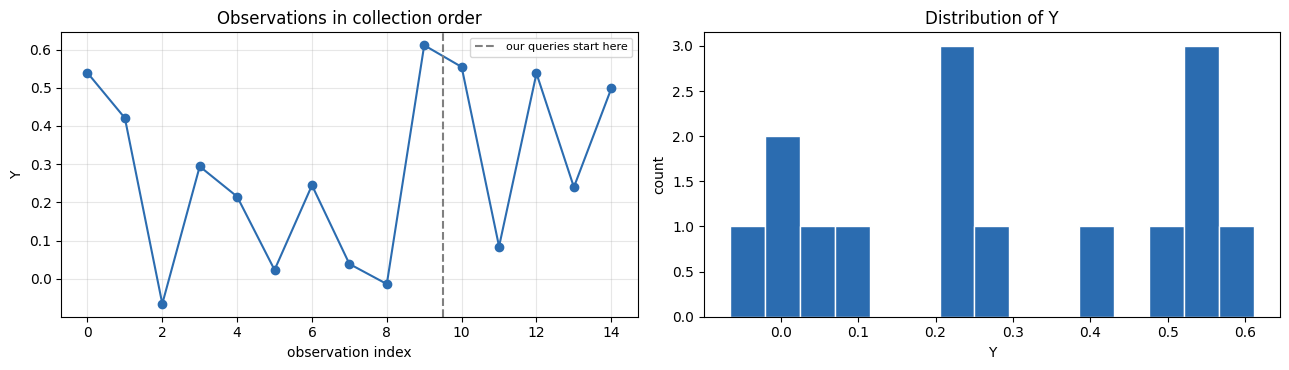

In [3]:
# Left  : scores in collection order, so our five queries sit on the right
# Right : how the scores are distributed
#
# These two plots are what tell us whether a transform is needed.

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(Y, "o-", color="#2b6cb0")
axes[0].axvline(np.sum(week == 0) - 0.5, color="grey", linestyle="--",
                label="our queries start here")
axes[0].set_xlabel("observation index")
axes[0].set_ylabel("Y")
axes[0].set_title("Observations in collection order")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(Y, bins=15, color="#2b6cb0", edgecolor="white")
axes[1].set_xlabel("Y")
axes[1].set_ylabel("count")
axes[1].set_title("Distribution of Y")

plt.tight_layout()
plt.show()

## 2. Transforming the target

**No transform is applied to Function 2.**

The outputs run from -0.066 to 0.611 — a compact range on a consistent scale,
with no extreme values and no orders-of-magnitude spread.

This is worth stating explicitly rather than passing over in silence. Function
1 required a signed log transform to be modellable at all, and it would be
easy to apply the same treatment here out of habit. Every transform changes
the shape of the surface the GP fits, and therefore which regions the
acquisition function favours, so applying one without cause does harm.

In [4]:
# No transform: the target is already on a compact, well-behaved scale.
# Y_model is defined anyway so the rest of the notebook reads identically
# to Function 1.

Y_model = Y.astype(float)

print(f"No transform applied.")
print(f"Range: {Y_model.min():.4f} to {Y_model.max():.4f}")

No transform applied.
Range: -0.0656 to 0.6112


## 3. Kernel

`ConstantKernel × Matérn(ν=5/2) + WhiteKernel`

The first version of this model used an **RBF** kernel. RBF assumes an
infinitely differentiable surface — appropriate only if the log-likelihood
landscape is globally smooth with no sharp ridges or discontinuities. That is a
strong assumption to make about a surface nobody has seen, so it was replaced
with Matérn, which permits sharper local features.

| Component | Setting | Role |
|---|---|---|
| `ConstantKernel` | bounds (1e-3, 1e3) | Learns overall signal amplitude. |
| `Matérn(ν=2.5)` | — | Smooth but not infinitely differentiable — appropriate for a surface that is continuous but may contain sharp ridges. |
| `length_scale` | 0.3, bounds (0.01, 2.0) | Longer than Function 1's 0.05, because this surface is globally smooth rather than sparse and peaked. |
| `WhiteKernel` | 0.1, bounds (1e-5, 10.0) | Models observation noise explicitly. Critical here, since each evaluation of this function is noisy. |

`normalize_y=True` stabilises fitting; `n_restarts_optimizer=25` avoids local
optima in the kernel hyperparameter fit.

In [5]:
# -----------------------------------------------------------------
#  KERNEL
# -----------------------------------------------------------------
kernel = (
    ConstantKernel(
        constant_value=1.0,
        constant_value_bounds=(1e-3, 1e3),      # learns signal amplitude
    )
    * Matern(
        nu=2.5,                                 # smooth, but allows ridges
        length_scale=0.3,
        length_scale_bounds=(0.01, 2.0),        # range the fit may search
    )
    + WhiteKernel(
        noise_level=0.1,                        # explicit noise term
        noise_level_bounds=(1e-5, 10.0),
    )
)

# -----------------------------------------------------------------
#  GP MODEL
#
#  n_restarts_optimizer=25 : fitting the kernel is itself a non-convex
#      search that can get stuck, so we try 25 starting points.
#  normalize_y=True        : centres and scales the target before fitting.
# -----------------------------------------------------------------
model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=True,
    random_state=42,
)
model.fit(X, Y_model)

print(f"Optimised kernel:\n  {model.kernel_}")

# A length-scale resting on its lower bound means the model wants to vary
# faster than permitted - usually a sign of sharp structure or a target
# that still needs transforming.
fitted_ls = model.kernel_.k1.k2.length_scale
if fitted_ls <= 0.011:
    print(f"\n  WARNING: length_scale {fitted_ls:.4f} is at its lower bound.")

Optimised kernel:
  0.965**2 * Matern(length_scale=0.0943, nu=2.5) + WhiteKernel(noise_level=1e-05)


## 4. Does the model actually work?

Fitting a GP always produces a smooth, plausible-looking surface. That is not
evidence the model has learned anything.

Leave-one-out cross-validation tests it directly: hide one observation, refit
on the rest, predict the hidden point, repeat for every point.

Two measures are reported.

**RMSE** is the average size of the prediction error, in the units of this
function's target. It is an absolute measure — it says how wrong the model is,
not merely how it compares with an alternative — which makes it the more
interpretable of the two and the better choice when comparing different kinds
of model.

**R²** expresses the same error as a proportion of the variance: 1.0 is
perfect, 0.0 is no better than always predicting the average, and below 0.0 is
worse than that. It is unitless, so it travels between functions on different
scales, but a high value alone does not make a model appropriate.

Both are shown, along with the RMSE of simply predicting the mean, which is the
benchmark any useful model has to beat. Whatever this returns applies to every
suggestion the model makes below.

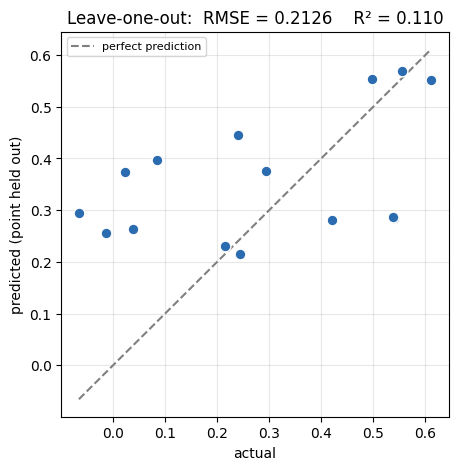

RMSE                       : 0.2126
RMSE if predicting the mean: 0.2253
Ratio                      : 0.944   (below 1 beats guessing)
R²                         : 0.110

Very low. The model barely improves on predicting the average,
so it has little basis for preferring one region over another.


In [6]:
# -----------------------------------------------------------------
#  LEAVE-ONE-OUT VALIDATION
# -----------------------------------------------------------------
predicted = np.empty(len(Y_model))

for train_idx, test_idx in LeaveOneOut().split(X):
    k = (ConstantKernel(1.0, (1e-3, 1e3))
         * Matern(nu=2.5, length_scale=0.3, length_scale_bounds=(0.01, 2.0))
         + WhiteKernel(0.1, (1e-5, 10.0)))
    g = GaussianProcessRegressor(kernel=k, n_restarts_optimizer=3,
                                 normalize_y=True, random_state=42)
    g.fit(X[train_idx], Y_model[train_idx])
    predicted[test_idx] = g.predict(X[test_idx])

residuals = Y_model - predicted
r2 = 1 - (residuals ** 2).sum() / ((Y_model - Y_model.mean()) ** 2).sum()

# RMSE: the average size of the prediction error, in the units of the
# target. Unlike R2 it is an absolute measure, so it says how wrong the
# model is rather than only how it compares with guessing.
rmse = np.sqrt((residuals ** 2).mean())

# RMSE we would get by always predicting the mean - the benchmark any
# useful model has to beat.
baseline = np.sqrt(((Y_model - Y_model.mean()) ** 2).mean())
ratio    = rmse / baseline

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(Y_model, predicted, s=60, c="#2b6cb0", edgecolors="white", zorder=3)
lims = [min(Y_model.min(), predicted.min()), max(Y_model.max(), predicted.max())]
ax.plot(lims, lims, "--", color="grey", label="perfect prediction")
ax.set_xlabel("actual")
ax.set_ylabel("predicted (point held out)")
ax.set_title(f"Leave-one-out:  RMSE = {rmse:.4g}    R² = {r2:.3f}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

print(f"RMSE                       : {rmse:.4g}")
print(f"RMSE if predicting the mean: {baseline:.4g}")
print(f"Ratio                      : {ratio:.3f}   (below 1 beats guessing)")
print(f"R²                         : {r2:.3f}")
if r2 < 0.2:
    print("\nVery low. The model barely improves on predicting the average,")
    print("so it has little basis for preferring one region over another.")
elif r2 < 0.5:
    print("\nModerate. The model has learned something but is not reliable.")
else:
    print("\nThe model predicts held-out points reasonably well.")

## 5. Expected Improvement

EI(x) = (μ(x) − Y_best − ξ) · Φ(Z) + σ(x) · φ(Z),  where Z = (μ(x) − Y_best − ξ) / σ(x)

**ξ = 0.01** — exploitation-leaning. Raising it toward 0.1 would push the search
into unexplored regions instead.

### Why EI rather than UCB

This was a deliberate choice for this function, for three reasons.

**UCB applies a fixed trade-off regardless of the current best.** It scores
μ + β·σ, which takes no account of how good the incumbent already is. In a
noisy setting σ is inflated everywhere by the noise itself, so UCB can be drawn
toward regions that are merely noisy rather than genuinely promising.

**EI conditions on beating Y_best.** It asks directly: what is the probability,
and the magnitude, of improving on what we already have? Regions whose mean
sits far below the incumbent are discounted even when uncertainty there is
high. That focus matters when the measurements are noisy.

**The problem description points to multiple optima.** It describes a mystery
ML model returning a log-likelihood score, and warns that depending on where
you start you might get stuck in a local optimum. A fixed β can keep UCB
circling one local peak; EI moves on once a region is well characterised.

The current best is **Y = 0.6112 at [0.7026, 0.9266]**. The GP exploits around
that region while EI directs samples toward unexplored areas that could beat
it.

The prediction grid is 100 × 100 = 10,000 points.

In [7]:
# -----------------------------------------------------------------
#  PREDICTION GRID
# -----------------------------------------------------------------
n_grid  = 100
x1_grid = np.linspace(0, 1, n_grid)
x2_grid = np.linspace(0, 1, n_grid)

X1_mesh, X2_mesh = np.meshgrid(x1_grid, x2_grid)
X_grid = np.column_stack([X1_mesh.ravel(), X2_mesh.ravel()])

post_mean, post_std = model.predict(X_grid, return_std=True)

post_mean_mesh = post_mean.reshape(n_grid, n_grid)
post_std_mesh  = post_std.reshape(n_grid, n_grid)


# -----------------------------------------------------------------
#  EXPECTED IMPROVEMENT
# -----------------------------------------------------------------
xi     = 0.01
Y_best = Y_model.max()          # best value on the modelling scale


def expected_improvement(mu, sigma, y_best, xi=0.01):
    improvement = mu - y_best - xi

    # Where sigma is effectively zero, Z would divide by zero. We set it to
    # 0.0 there and zero out the resulting EI, since a point with no
    # uncertainty offers no possibility of a surprise.
    Z  = np.where(sigma > 1e-9, improvement / sigma, 0.0)
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma <= 1e-9] = 0.0
    return ei


ei_values = expected_improvement(post_mean, post_std, Y_best, xi)
ei_mesh   = ei_values.reshape(n_grid, n_grid)


# -----------------------------------------------------------------
#  NEXT SAMPLE
# -----------------------------------------------------------------
max_idx = np.argmax(ei_values)
x_next  = X_grid[max_idx]

print(f"Current best Y        : {Y.max():.6g}")
print(f"  at X                : {X[np.argmax(Y)]}")
print(f"\nNext point to sample  : [{x_next[0]:.6f}, {x_next[1]:.6f}]")
print(f"Max EI value          : {ei_values[max_idx]:.6f}")

Current best Y        : 0.611205
  at X                : [0.702637 0.926564]

Next point to sample  : [0.626263, 0.202020]
Max EI value          : 0.021723


## 6. Visualisation

Three panels: what the model expects, how confident it is, and where EI is
highest.

The middle panel is the most diagnostic. EI can only send the search somewhere
sensible if uncertainty is low near the observations and high away from them.
If uncertainty looks uniformly high across the whole space, the model has not
learned the surface and the third panel is not telling us anything useful.

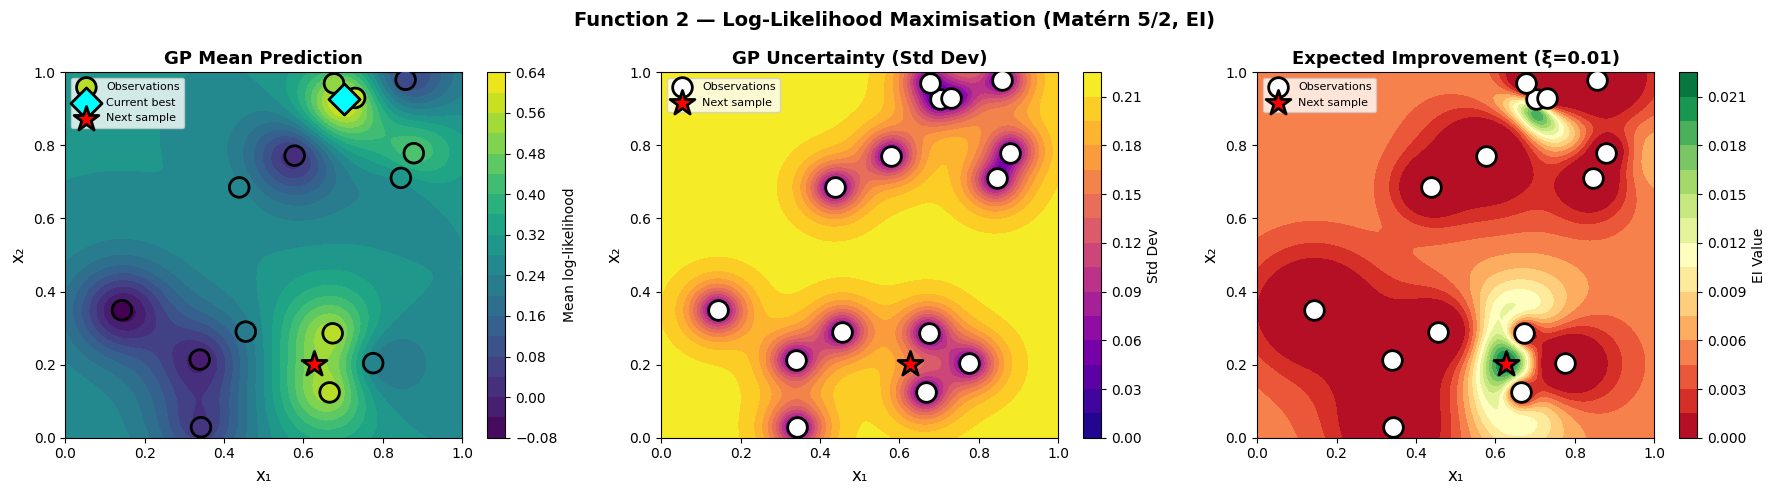

In [8]:
# -----------------------------------------------------------------
#  VISUALISATION
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Function 2 — Log-Likelihood Maximisation (Matérn 5/2, EI)", fontsize=14, fontweight="bold")

scatter_kwargs = dict(s=200, marker="o", edgecolors="black",
                      linewidths=2, zorder=10)
star_kwargs    = dict(c="red", s=350, marker="*", edgecolors="black",
                      linewidths=2, zorder=11, label="Next sample")

# --- Plot 1: GP mean ---
ax = axes[0]
cf = ax.contourf(X1_mesh, X2_mesh, post_mean_mesh, levels=20, cmap="viridis")
ax.scatter(X[:, 0], X[:, 1], c=Y_model, cmap="viridis",
           vmin=Y_model.min(), vmax=Y_model.max(),
           **scatter_kwargs, label="Observations")
ax.scatter(X[np.argmax(Y), 0], X[np.argmax(Y), 1],
           c="cyan", s=250, marker="D", edgecolors="black",
           linewidths=2, zorder=10, label="Current best")
ax.scatter(x_next[0], x_next[1], **star_kwargs)
ax.set_xlabel("x\u2081", fontsize=12)
ax.set_ylabel("x\u2082", fontsize=12)
ax.set_title("GP Mean Prediction", fontsize=13, fontweight="bold")
ax.legend(fontsize=8)
plt.colorbar(cf, ax=ax, label="Mean log-likelihood")

# --- Plot 2: GP uncertainty ---
ax = axes[1]
cf = ax.contourf(X1_mesh, X2_mesh, post_std_mesh, levels=20, cmap="plasma")
ax.scatter(X[:, 0], X[:, 1], c="white", **scatter_kwargs, label="Observations")
ax.scatter(x_next[0], x_next[1], **star_kwargs)
ax.set_xlabel("x\u2081", fontsize=12)
ax.set_ylabel("x\u2082", fontsize=12)
ax.set_title("GP Uncertainty (Std Dev)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8)
plt.colorbar(cf, ax=ax, label="Std Dev")

# --- Plot 3: Expected Improvement ---
ax = axes[2]
cf = ax.contourf(X1_mesh, X2_mesh, ei_mesh, levels=20, cmap="RdYlGn")
ax.scatter(X[:, 0], X[:, 1], c="white", **scatter_kwargs, label="Observations")
ax.scatter(x_next[0], x_next[1], **star_kwargs)
ax.set_xlabel("x\u2081", fontsize=12)
ax.set_ylabel("x\u2082", fontsize=12)
ax.set_title(f"Expected Improvement (\u03be={xi})",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8)
plt.colorbar(cf, ax=ax, label="EI Value")

plt.tight_layout()
plt.show()

## 7. Round-by-round review

No improvement over five rounds — the best value is still the 0.611 supplied
in the starting data.

But this is a different failure from Function 1. The queries went to sensible
places: round 1 reached 0.554 and round 3 reached 0.538, both near the
incumbent rather than off in a corner. The search was looking in roughly the
right region and simply did not find anything better.

Two things are worth separating here. The R² above is low, so the model is
weak — 15 points is little to work with. But this function is also explicitly
noisy, and with no repeated measurements there is no way to tell how much of
the incumbent 0.611 is real signal. Re-querying that exact point would be
informative: if it returns 0.45, the target being chased does not exist.

ξ = 0.01 is strongly exploitative. Given five rounds produced nothing, raising
it toward 0.05 would be a reasonable response.

In [9]:
# -----------------------------------------------------------------
#  ROUND-BY-ROUND LOG
# -----------------------------------------------------------------
rows = []
for r in range(1, week.max() + 1):
    i = np.where(week == r)[0][0]
    rows.append({
        "round":      r,
        "submitted":  f"[{X[i, 0]:.4f}, {X[i, 1]:.4f}]",
        "Y":          Y[i],
        "best after": Y[week <= r].max(),
        "improved":   "yes" if Y[i] > Y[week < r].max() else "no",
    })

pd.DataFrame(rows)

,round,submitted,Y,best after,improved
0,1,"[0.7300, 0.9300]",0.554417,0.611205,no
1,2,"[0.8571, 0.9796]",0.084334,0.611205,no
2,3,"[0.6735, 0.2857]",0.537646,0.611205,no
3,4,"[0.7755, 0.2041]",0.239744,0.611205,no
4,5,"[0.6768, 0.9697]",0.498074,0.611205,no


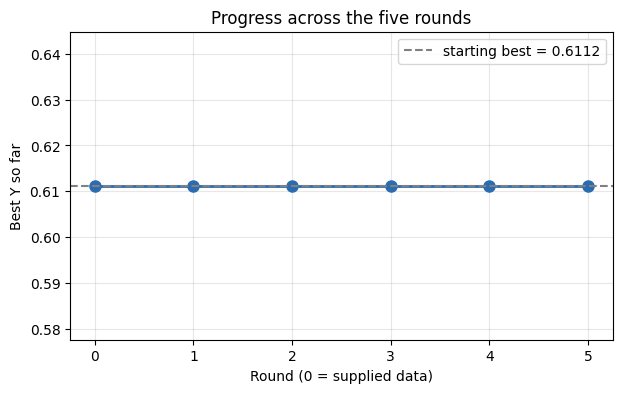

In [10]:
# Best value found so far, after each round. A flat line means a whole
# round passed without improving on what was already known.

rounds      = np.arange(week.max() + 1)
best_so_far = [Y[week <= r].max() for r in rounds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rounds, best_so_far, "o-", linewidth=2, markersize=8, color="#2b6cb0")
ax.axhline(best_so_far[0], color="grey", linestyle="--",
           label=f"starting best = {best_so_far[0]:.4g}")
ax.set_xlabel("Round (0 = supplied data)")
ax.set_ylabel("Best Y so far")
ax.set_title("Progress across the five rounds")
ax.set_xticks(rounds)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [11]:
# -----------------------------------------------------------------
#  SUMMARY
# -----------------------------------------------------------------
best_obs_idx = np.argmax(Y)

print("=" * 55)
print("Summary")
print("=" * 55)
print(f"  Total observations   : {len(X)}")
print(f"  Best Y so far        : {Y[best_obs_idx]:.6g}")
print(f"  at X                 : {X[best_obs_idx]}")
print(f"  Found in round       : {week[best_obs_idx]}")
print(f"  Transform            : none")
print(f"  Kernel               : Matern 5/2 + WhiteKernel")
print(f"  Model quality (R2)   : {r2:.3f}")
print(f"  EI xi parameter      : {xi}")
print(f"  Next point           : [{x_next[0]:.6f}, {x_next[1]:.6f}]")
print(f"  Max EI value         : {ei_values[max_idx]:.6f}")
print("=" * 55)

Summary
  Total observations   : 15
  Best Y so far        : 0.611205
  at X                 : [0.702637 0.926564]
  Found in round       : 0
  Transform            : none
  Kernel               : Matern 5/2 + WhiteKernel
  Model quality (R2)   : 0.110
  EI xi parameter      : 0.01
  Next point           : [0.626263, 0.202020]
  Max EI value         : 0.021723


---

See `MODEL_CARD.md` for how this function compares with the other seven and
for the full list of assumptions and limitations, and `DATASHEET.md` for known
gaps and biases in the data.